In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from database.manager import DatabaseManager

from analysis.seasonality import Seasonality
from analysis.plotting import SeasonalityPlotter
from analysis.feature_creation import FeatureCreator
from Mini_Tools.export_to_excel import export_to_excel

import pandas as pd

db = DatabaseManager()
sznlty = Seasonality(db)
plotter = SeasonalityPlotter()
fc = FeatureCreator()

In [14]:
# result = sznlty.expression_seasonality("CO", "F27 - 3*G27 + 3*H27 - J27 ", start_year=2020, end_year=2027, window_days=400)
result = sznlty.working_day_expression_seasonality("CO", "K27-2*M27+N27", start_year=2020, end_year=2027, window_days=350)
# result = sznlty.expression_seasonality("CO", "J27 - 3*M27 + 3*Q27 - V27 ", start_year=2018, end_year=2027, window_days=350)
plotter.plot_seasonality(result, title="seasonality")
# # 2. Identify Anomaly Years (using the RMSE/Volatility logic)
# anomaly_map = fc.get_anomaly_years(result['combined'])

# # 3. Create Enhanced DataFrame with Cleaned Averages
# # This adds Avg_5y_Clean, Avg_10y_Clean, and Avg_15y_Clean
# df_enhanced = fc.get_cleaned_averages(result['combined'], anomaly_map)

# # 4. Calculate Statistical Metrics
# # Adds UpRate, Expected, and MaxDrawdown for 3D, 6D, 10D, 15D, 21D intervals
# stats_df = fc.calculate_stats(result['combined'])

# # 5. Join stats with the enhanced dataframe
# df_final = df_enhanced.join(stats_df)

# # 6. Export to Excel
# # result: for original stats and dates, df_final: for all new columns
# export_to_excel(result, df_final, filename="seasonality_report_final.xlsx")

# # 7. Quick Verification
# print("--- Analysis Complete ---")
# print(f"Anomalies Found: {anomaly_map}")
# print(f"Total Columns Exported: {len(df_final.columns)}")

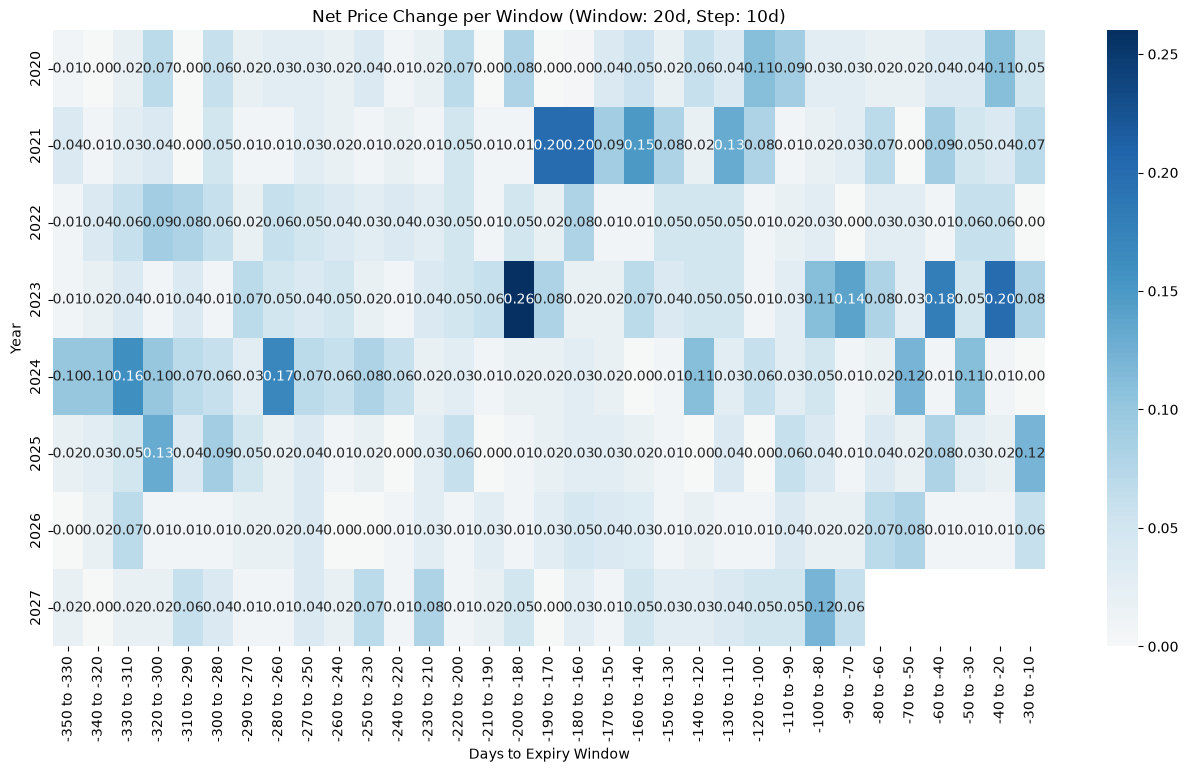

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- SETTINGS ---
FILENAME = "seasonality_report_final.xlsx"
WIN_LEN = 20
STEP = 10
CUTOFF = 10

# 1. Load from Excel and prepare df_clean
df_raw = pd.read_excel(FILENAME, index_col=0)
# Keep only columns that are years (4-digit numeric)
year_cols = [c for c in df_raw.columns if str(c).isdigit() and len(str(c)) == 4]
df_clean = df_raw[year_cols][df_raw.index <= -CUTOFF].sort_index()


windowed_changes = []
all_indices = df_clean.index.tolist()
min_idx, max_idx = min(all_indices), max(all_indices)

# 1. Sliding Window Loop to calculate Net Change
current_start = min_idx
while current_start + WIN_LEN <= max_idx:
    current_end = current_start + WIN_LEN
    label = f"{int(current_start)} to {int(current_end)}"
    
    slice_df = df_clean.loc[current_start:current_end]
    
    for year in slice_df.columns:
        s = slice_df[year].dropna()
        if len(s) < 2: continue 
        
        # Calculate Net Change (End - Start)
        net_change = abs(s.iloc[-1] - s.iloc[0])
        
        windowed_changes.append({'Year': year, 'Window': label, 'Change': net_change})
    
    current_start += STEP

# 2. Pivot Table
change_table = pd.DataFrame(windowed_changes).pivot(index='Window', columns='Year', values='Change')
change_table = change_table.sort_index(key=lambda x: [int(i.split(' ')[0]) for i in x])

# 3. Plot Heatmap
plt.figure(figsize=(16, 8))
# Using a Diverging Color Map (RdBu): 
# Blue = Upward Trend, Red = Downward Trend, White = Consolidation (0 Change)
sns.heatmap(change_table.T, annot=True, fmt=".2f", cmap="RdBu", center=0)

plt.title(f"Net Price Change per Window (Window: {WIN_LEN}d, Step: {STEP}d)")
plt.xlabel("Days to Expiry Window")
plt.ylabel("Year")
plt.show()

Percentage of buckets with absolute change < 0.1:
Year
2020     93.9
2021     87.9
2022    100.0
2023     84.8
2024     81.8
2025     93.9
2026    100.0
2027     96.3
dtype: float64


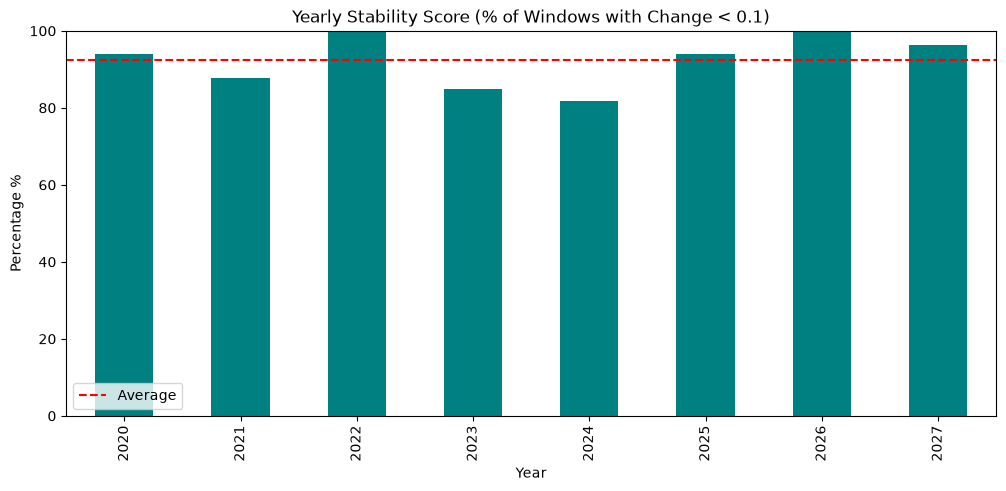

In [10]:
THRESHOLD = 0.1

# 1. Calculate the frequency of "Stable" buckets
# We use abs() to catch both small positive and small negative changes
stable_buckets = (change_table.abs() < THRESHOLD).sum()
total_buckets = change_table.count() # Counts only non-NaN windows

stability_percentage = (stable_buckets / total_buckets) * 100

# 2. Display Results
print(f"Percentage of buckets with absolute change < {THRESHOLD}:")
print(stability_percentage.round(1))

# 3. Visual Comparison
stability_percentage.plot(kind='bar', figsize=(12, 5), color='teal' )
plt.axhline(stability_percentage.mean(), color='red', linestyle='--', label='Average')
plt.ylim(0, 100)

plt.title(f"Yearly Stability Score (% of Windows with Change < {THRESHOLD})")
plt.ylabel("Percentage %")
plt.legend()
plt.show()

In [7]:
# import json
# import pandas as pd

# from Mini_Tools.expression import months_to_expression
# from backtesting.engine import SeasonalBacktester
# from backtesting.strategies import SeasonalStrategies

# with open("combinations.json", "r") as f:
#     combinations = json.load(f)

# expressions = [months_to_expression(x) for x in combinations["Defly"]]

# symbol = "CO"
# summary_results = []

# print(f"Starting Scan for {len(expressions)} expressions...")

# for index, expression in enumerate(expressions, 1):

#     print(f"[{index}/{len(expressions)}] Analyzing: {expression}")

#     try:
#         result = sznlty.working_day_expression_seasonality(
#             symbol,
#             expression,
#             start_year=2012,
#             end_year=2027,
#             window_days=400
#         )

#         if not result["series"]:
#             continue

#         bt = SeasonalBacktester(result)

#         trade_history = bt.run_walk_forward(
#             strategy_func=SeasonalStrategies.CO_Defly01,
#             data_start_year=2012,
#             test_start_year=2025
#         )

#         summary_results.append({
#             "Expression": expression,
#             "Total_Trades": len(trade_history),
#             "Success_Rate": trade_history["Success"].mean() * 100 if not trade_history.empty else 0
#         })

#     except Exception as e:
#         print(e)

# df_summary = pd.DataFrame(summary_results).sort_values("Success_Rate", ascending=False)

# display(df_summary)

# df_summary.to_excel("Strategy_Comparison_Results.xlsx", index=False)

In [8]:
# import json
# from Mini_Tools.expression import months_to_expression

# with open("combinations.json", "r") as f:
#     data = json.load(f)

# expressions = []

# for strategy, combos in data.items():

#     print(f"\n{strategy}")

#     for combo in combos:

#         expr = months_to_expression(combo)

#         expressions.append(expr)

#         print(expr)